# AI-Based Student Performance Prediction

## Problem Statement
Student performance is influenced by several factors such as study hours, previous scores, sleep hours, extracurricular activities, and practice. Predicting student performance can help educators identify students who may need additional support.

## Objective
To build a Machine Learning model that predicts the Performance Index of a student using academic and lifestyle factors.

## Dataset
Student Performance Dataset (Kaggle)

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [3]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv("Student_data.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
# Load the dataset

df = pd.read_csv("Student_data.csv")

In [6]:
# Display the first five rows

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [7]:
# Display basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [8]:
# Number of rows and columns

df.shape

(10000, 6)

In [9]:
# Column names

df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [10]:
# Check missing values

df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [11]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


## Dataset Understanding

### Observations

- The dataset contains 10,000 student records.
- There are 6 columns.
- No missing values were found.
- The dataset contains one categorical feature:
  - Extracurricular Activities
- The remaining columns are numerical.
- The target variable is **Performance Index**.

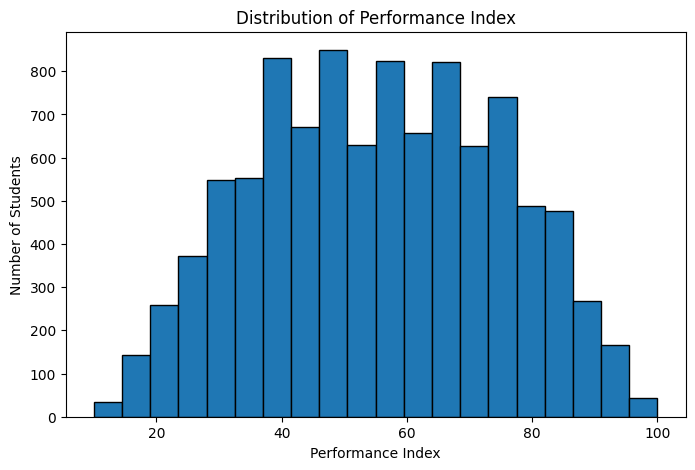

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Performance Index"], bins=20, edgecolor="black")

plt.title("Distribution of Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("Number of Students")

plt.show()

### Observation

The Performance Index values are distributed across a wide range, indicating that the dataset contains students with different performance levels.

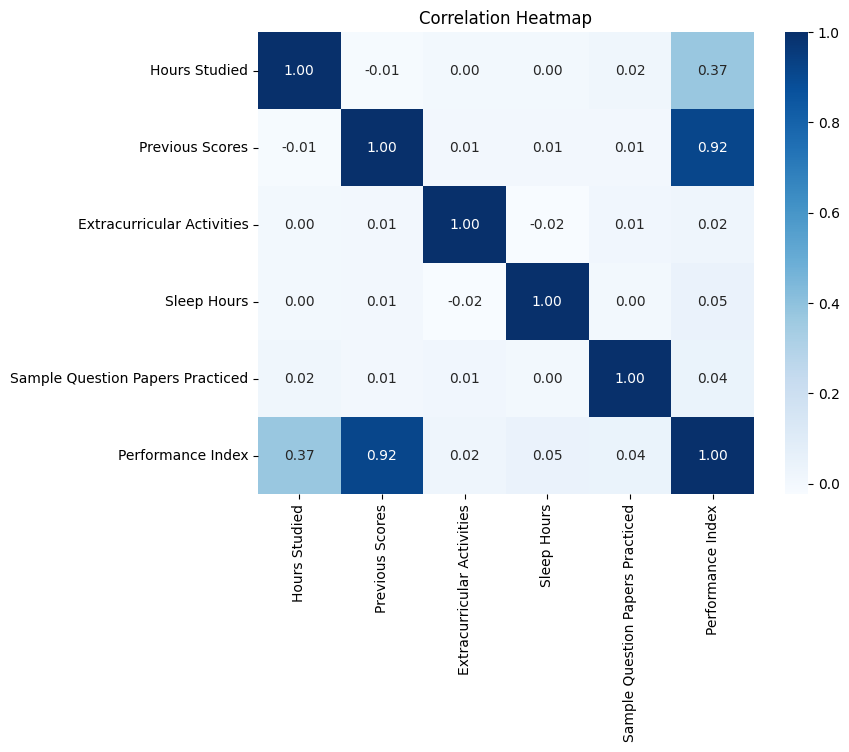

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical column into numeric
temp_df = df.copy()

temp_df["Extracurricular Activities"] = temp_df["Extracurricular Activities"].map({
    "Yes": 1,
    "No": 0
})

# Plot correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(temp_df.corr(), annot=True, cmap="Blues", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Previous Scores have a strong positive correlation with Performance Index.
- Hours Studied also positively influences student performance.
- Sleep Hours and Extracurricular Activities have a smaller impact.

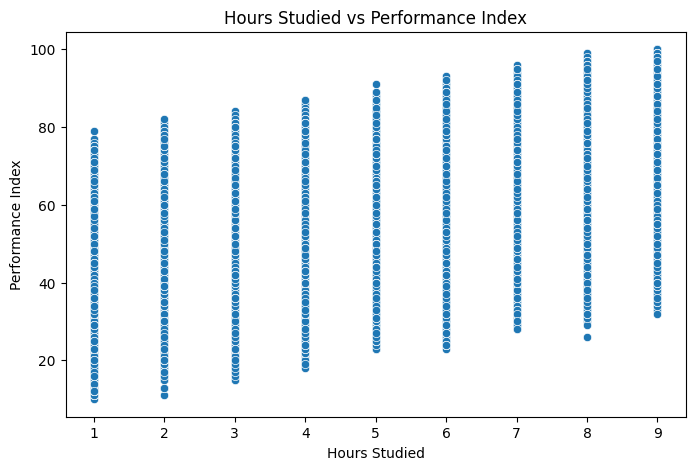

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Hours Studied",
    y="Performance Index",
    data=df
)

plt.title("Hours Studied vs Performance Index")

plt.show()

### Observation

Students who study for more hours generally achieve a higher Performance Index.

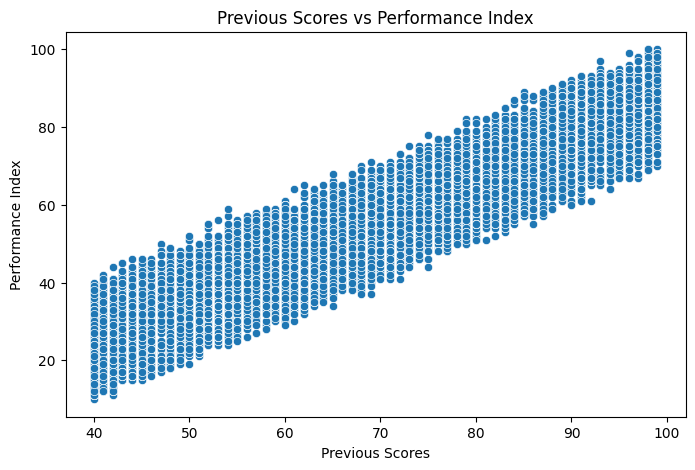

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Previous Scores",
    y="Performance Index",
    data=df
)

plt.title("Previous Scores vs Performance Index")

plt.show()

### Observation

Students with higher previous scores tend to achieve better performance in the current evaluation.

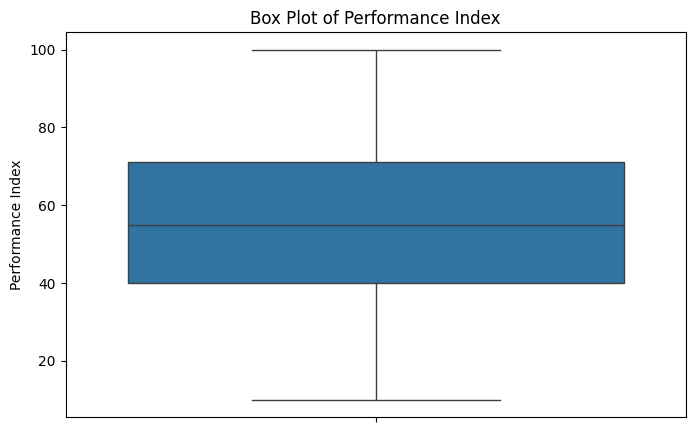

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Performance Index"]
)

plt.title("Box Plot of Performance Index")

plt.show()

### Observation

The box plot helps identify the spread of Performance Index values and shows whether any outliers are present.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
encoder = LabelEncoder()

# Convert Yes/No into 1/0
df["Extracurricular Activities"] = encoder.fit_transform(df["Extracurricular Activities"])

# Display first 5 rows
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


### Observation

The 'Extracurricular Activities' column has been converted into numerical values.

No  → 0

Yes → 1

In [18]:
# Input features
X = df.drop("Performance Index", axis=1)

# Target variable
y = df["Performance Index"]

In [19]:
X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [20]:
y.head()

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


### Features

- Hours Studied
- Previous Scores
- Extracurricular Activities
- Sleep Hours
- Sample Question Papers Practiced

### Target

- Performance Index

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (8000, 5)
Testing Data  : (2000, 5)


### Observation

The dataset has been divided into:

- 80% Training Data
- 20% Testing Data

The training data is used to train the model, while the testing data is used to evaluate its performance.

In [24]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

LinearRegression()

In [25]:
# Make predictions
lr_predictions = lr_model.predict(X_test)

In [26]:
#Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mean_absolute_error(y_test, lr_predictions))
print("MSE :", mean_squared_error(y_test, lr_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_predictions)))
print("R² Score:", r2_score(y_test, lr_predictions))

Linear Regression Results
-------------------------
MAE : 1.6111213463123044
MSE : 4.082628398521853
RMSE: 2.0205515085050054
R² Score: 0.9889832909573145


### Observation

The Linear Regression model was trained successfully.

Evaluation metrics such as MAE, RMSE, and R² Score were calculated to measure prediction accuracy.

In [27]:
#Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [28]:
dt_predictions = dt_model.predict(X_test)

In [29]:
print("Decision Tree Results")
print("-------------------------")

print("MAE :", mean_absolute_error(y_test, dt_predictions))
print("MSE :", mean_squared_error(y_test, dt_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_predictions)))
print("R² Score:", r2_score(y_test, dt_predictions))

Decision Tree Results
-------------------------
MAE : 2.3378333333333337
MSE : 8.812694444444444
RMSE: 2.968618271931311
R² Score: 0.9762195132401258


In [30]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [31]:
rf_predictions = rf_model.predict(X_test)

In [32]:
print("Random Forest Results")
print("-------------------------")

print("MAE :", mean_absolute_error(y_test, rf_predictions))
print("MSE :", mean_squared_error(y_test, rf_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))
print("R² Score:", r2_score(y_test, rf_predictions))

Random Forest Results
-------------------------
MAE : 1.8147207361111108
MSE : 5.158838006796808
RMSE: 2.271307554426923
R² Score: 0.9860792088401176


In [33]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, dt_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, dt_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.611121,2.020552,0.988983
1,Decision Tree,2.337833,2.968618,0.976220
2,Random Forest,1.814721,2.271308,0.986079


In [34]:
results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.611121,2.020552,0.988983
2,Random Forest,1.814721,2.271308,0.986079
1,Decision Tree,2.337833,2.968618,0.976220


In [41]:
import joblib
joblib.dump(lr_model, "student_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [42]:
sample = [[7, 85, 1, 7, 5]]

prediction = lr_model.predict(sample)

print("Predicted Performance Index:", prediction[0])

Predicted Performance Index: 77.39580248031393


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Conclusion

- Three supervised machine learning models were trained:
  - Linear Regression
  - Decision Tree Regressor
  - Random Forest Regressor

- The models were evaluated using:
  - MAE
  - MSE
  - RMSE
  - R² Score

- The model with the highest R² Score was selected as the final prediction model and saved for future use.

In [43]:
model = joblib.load("student_model.pkl")

In [44]:
y_pred = model.predict(X_test)

In [45]:
print("Model Evaluation")
print("----------------")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

Model Evaluation
----------------
MAE : 1.6111213463123044
MSE : 4.082628398521853
RMSE: 2.0205515085050054
R² Score: 0.9889832909573145


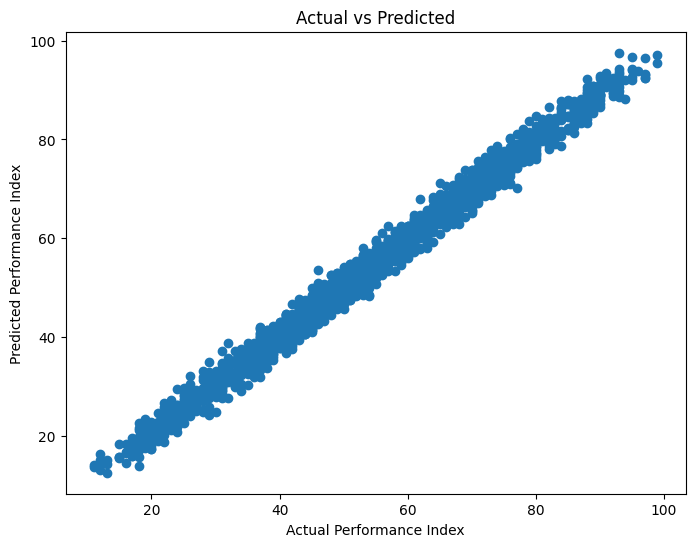

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted")

plt.savefig("actual_vs_predicted.png")

plt.show()

In [47]:
sample = [[8,90,1,7,6]]

prediction = model.predict(sample)

print("Predicted Performance Index :", prediction[0])

Predicted Performance Index : 85.52505884650171


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [48]:
score = prediction[0]

if score >= 90:
    print("Category : Excellent")
elif score >= 75:
    print("Category : Good")
elif score >= 50:
    print("Category : Average")
else:
    print("Category : Needs Improvement")

Category : Good


# Conclusion

This project developed a supervised machine learning model to predict a student's Performance Index using academic and lifestyle factors.

Three regression models were trained and compared:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The best-performing model was selected based on R² Score and error metrics (MAE and RMSE). The trained model can help estimate student performance and support educational decision-making.